In [1]:
## For using EigenMaps a) decompose the joint library and b) filter for shared and differential mechanisms between HepG2 (Liver Hepatocyte) and K562 (blood fibroblast)

In [2]:
## Load joint library DeepSHAP maps for two cell lines
import os, sys, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Populate precomputed attributions
raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

print(f'{len(df)} seqs loaded')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs loaded


In [3]:
## Eigen decompose entire library
em.eigendecompose(enhancer_only=True)

ei1_vecs = np.array([r['eigenvectors'][:, 0] for r in em.eigen_results])
ei1_var = np.array([r['var_ratio'][0] for r in em.eigen_results])
print(f'Done. EI_1 var: mean={ei1_var.mean():.1%}, median={np.median(ei1_var):.1%}')

Eigendecomposed 56975 sequences (enhancer only, 230bp)
Done. EI_1 var: mean=77.0%, median=78.5%


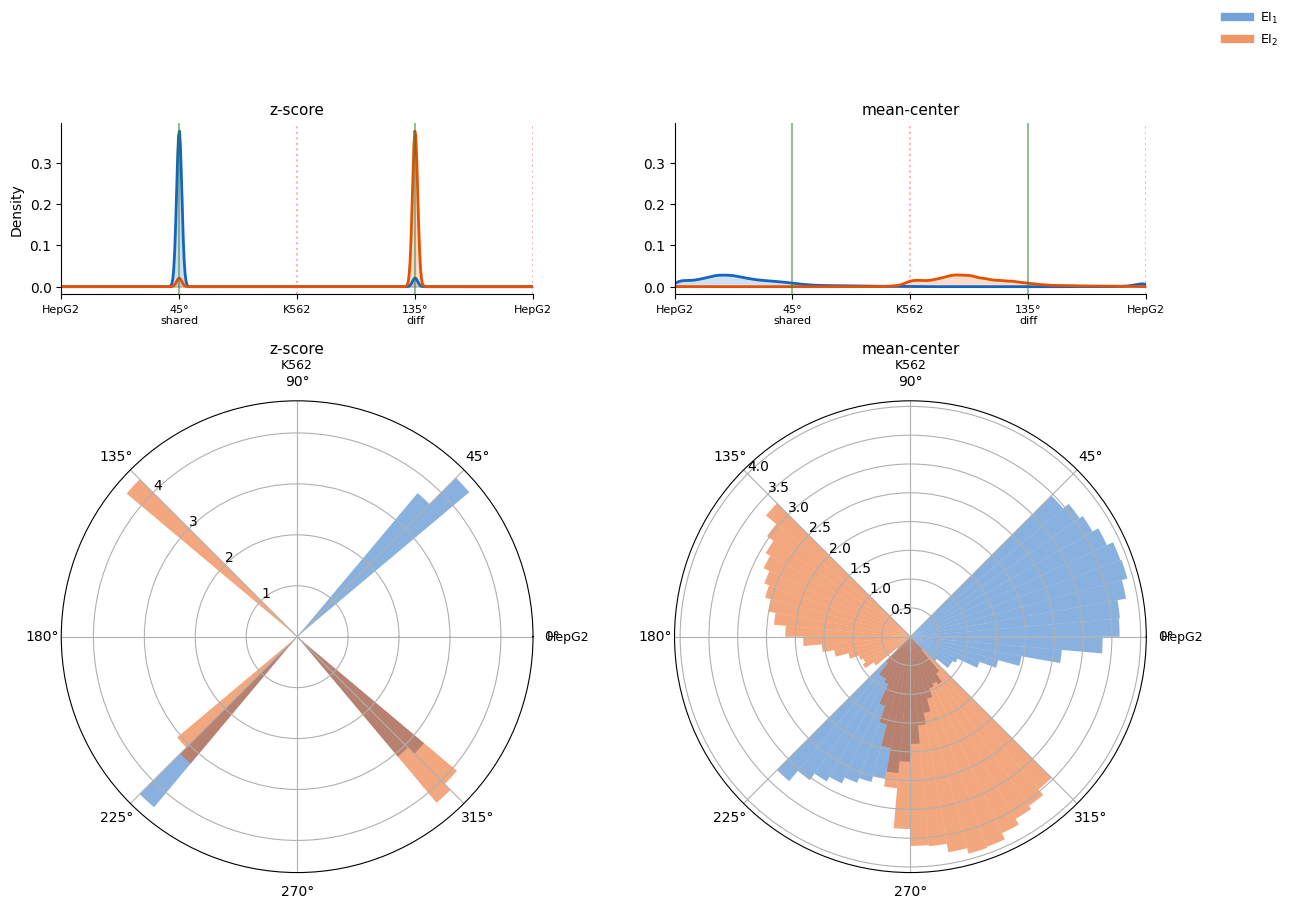

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

ENHANCER_LEN = 230

# arctan2(K562, HepG2) so 0° = pure HepG2, 90° = pure K562
ei2_vecs = np.array([r['eigenvectors'][:, 1] for r in em.eigen_results])
angles_ei1_zscore = np.degrees(np.arctan2(ei1_vecs[:, 0], ei1_vecs[:, 1])) % 360
angles_ei2_zscore = np.degrees(np.arctan2(ei2_vecs[:, 0], ei2_vecs[:, 1])) % 360

# mean-center only
ei1_vecs_mc, ei2_vecs_mc = [], []
for si in range(em.X.shape[0]):
    E = np.column_stack([em.importance[ct][si] for ct in em.cell_types])[:ENHANCER_LEN].copy()
    for ci in range(E.shape[1]):
        E[:, ci] -= E[:, ci].mean()
    C = E.T @ E / E.shape[0]
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evecs = evecs[:, order]
    ei1_vecs_mc.append(evecs[:, 0])
    ei2_vecs_mc.append(evecs[:, 1])
ei1_vecs_mc = np.array(ei1_vecs_mc)
ei2_vecs_mc = np.array(ei2_vecs_mc)
angles_ei1_mc = np.degrees(np.arctan2(ei1_vecs_mc[:, 0], ei1_vecs_mc[:, 1])) % 360
angles_ei2_mc = np.degrees(np.arctan2(ei2_vecs_mc[:, 0], ei2_vecs_mc[:, 1])) % 360

def fold_180(a): return np.where(a >= 180, a - 180, a)

x_kde = np.linspace(0, 180, 500)

tick_angles = [0, 45, 90, 135, 180]
tick_labels = ['HepG2', '45°\nshared', 'K562', '135°\ndiff', 'HepG2']

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 3], hspace=0.25, wspace=0.3)
ax_h1 = fig.add_subplot(gs[0, 0])
ax_h2 = fig.add_subplot(gs[0, 1], sharey=ax_h1)

# Top: KDE histograms (folded to 0-180)
for ax, a1, a2, title in [
    (ax_h1, fold_180(angles_ei1_zscore), fold_180(angles_ei2_zscore), 'z-score'),
    (ax_h2, fold_180(angles_ei1_mc), fold_180(angles_ei2_mc), 'mean-center'),
]:
    for angles, color in [(a1, '#1565C0'), (a2, '#E65100')]:
        kde = gaussian_kde(angles, bw_method=0.05)
        ax.plot(x_kde, kde(x_kde), color=color, lw=2)
        ax.fill_between(x_kde, kde(x_kde), alpha=0.2, color=color)
    for angle in [45, 135]:
        ax.axvline(angle, color='#2E7D32', lw=1.5, alpha=0.5)
    for angle in [0, 90, 180]:
        ax.axvline(angle, color='#F44336', lw=1.5, ls=':', alpha=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 180); ax.set_xticks(tick_angles)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax_h1.set_ylabel('Density', fontsize=10)

# Bottom: polar histograms with log-scale radial axis
n_bins = 72
for i, (v1_all, v2_all, title) in enumerate([
    (ei1_vecs, ei2_vecs, 'z-score'),
    (ei1_vecs_mc, ei2_vecs_mc, 'mean-center'),
]):
    ax = fig.add_subplot(gs[1, i], projection='polar')
    for v_all, color, label in [(v1_all, '#1565C0', 'EI$_1$'), (v2_all, '#E65100', 'EI$_2$')]:
        angles_rad = np.arctan2(v_all[:, 0], v_all[:, 1])
        counts, bin_edges = np.histogram(angles_rad, bins=n_bins, range=(-np.pi, np.pi))
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        log_counts = np.log10(np.maximum(counts, 1))
        ax.bar(bin_centers, log_counts, width=2*np.pi/n_bins, alpha=0.5, color=color, label=label)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_title(title, fontsize=11, pad=15)
    ax.set_rlabel_position(135)
    # Label HepG2/K562 axes
    ax.text(0, ax.get_rmax()*1.15, 'HepG2', ha='center', va='center', fontsize=9)
    ax.text(np.pi/2, ax.get_rmax()*1.15, 'K562', ha='center', va='center', fontsize=9)

handles = [Line2D([0], [0], color='#1565C0', lw=6, alpha=0.6, label='EI$_1$'),
           Line2D([0], [0], color='#E65100', lw=6, alpha=0.6, label='EI$_2$')]
fig.legend(handles=handles, loc='upper right', fontsize=9, frameon=False)
plt.show()

In [5]:
raw = angles_ei1_mc
for lo, hi, lab in [(0,45,'0-45'), (45,135,'45-135'),
                     (135,225,'135-225'), (225,315,'225-315'),
                     (315,360,'315-360')]:
    print(f'{lab:35s}: {((raw >= lo) & (raw < hi)).sum():6d}')

0-45                               :  47940
45-135                             :      0
135-225                            :      0
225-315                            :   6237
315-360                            :   2798


Number of seqs: 56975


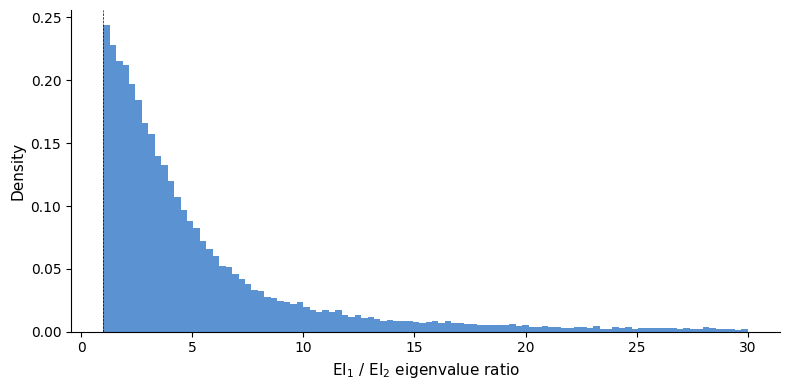

Ratio: median=3.6, mean=6.0, ratio=1 (independent): 1454 seqs, ratio>10 (dominant EI_1): 8135 seqs, Number of seqs: 56975


In [6]:
ei1_evals = np.array([r['eigenvalues'][0] for r in em.eigen_results])
ei2_evals = np.array([r['eigenvalues'][1] for r in em.eigen_results])
ratio = ei1_evals / np.clip(ei2_evals, 1e-10, None)
corrs = np.array([r['cov'][0, 1] for r in em.eigen_results])
print(f"Number of seqs: {len(ei1_evals)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratio, bins=100, range=(1, 30), color='#1565C0', alpha=0.7, density=True)
ax.axvline(1, color='k', lw=0.5, ls='--')
ax.set_xlabel('EI$_1$ / EI$_2$ eigenvalue ratio', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Ratio: median={np.median(ratio):.1f}, mean={ratio.mean():.1f}, '
      f'ratio=1 (independent): {(ratio < 1.1).sum()} seqs, '
      f'ratio>10 (dominant EI_1): {(ratio > 10).sum()} seqs, '
      f'Number of seqs: {len(ratio)}')

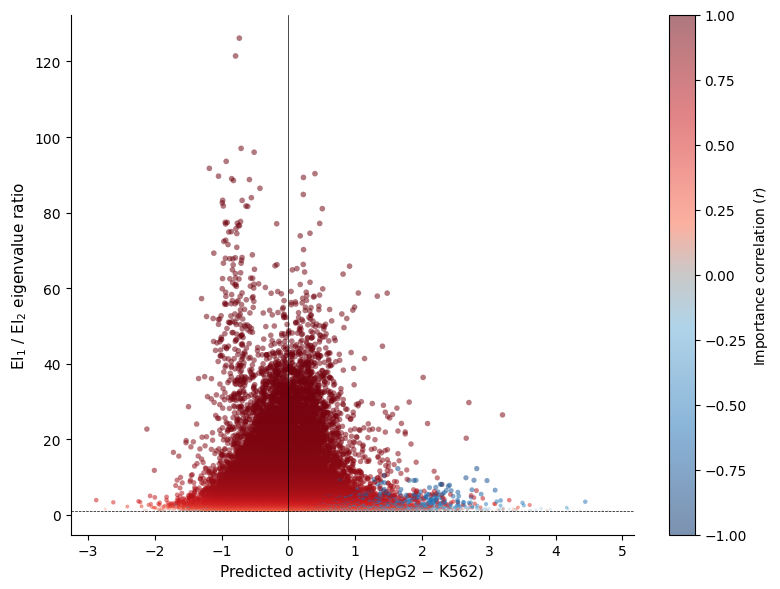

In [7]:
import matplotlib.colors as mcolors

activity_diff = em.predictions['HepG2'] - em.predictions['K562']

cmap = mcolors.LinearSegmentedColormap.from_list('rcmap', [
    (0.0, '#08306b'),
    (0.2, '#2171b5'),
    (0.4, '#6baed6'),
    (0.5, '#999999'),
    (0.6, '#fb6a4a'),
    (0.8, '#cb181d'),
    (1.0, '#67000d'),
])

order = np.argsort(np.abs(corrs))

# Size and alpha scale with |r| so extremes are big and opaque
sizes = 2 + 15 * np.abs(corrs[order])
alphas = 0.15 + 0.6 * np.abs(corrs[order])

fig, ax = plt.subplots(figsize=(8, 6))

# Draw in two passes: background (low |r|) then foreground (high |r|)
for lo, hi in [(0, 0.3), (0.3, 1.01)]:
    mask = (np.abs(corrs[order]) >= lo) & (np.abs(corrs[order]) < hi)
    sc = ax.scatter(activity_diff[order][mask], ratio[order][mask],
                    s=sizes[mask], alpha=alphas[mask].mean(),
                    c=corrs[order][mask], cmap=cmap, vmin=-1, vmax=1,
                    edgecolors='none', rasterized=True)

plt.colorbar(sc, ax=ax, label='Importance correlation ($r$)')

ax.axvline(0, color='k', lw=0.5)
ax.axhline(1, color='k', lw=0.5, ls='--')
ax.set_xlabel('Predicted activity (HepG2 − K562)', fontsize=11)
ax.set_ylabel('EI$_1$ / EI$_2$ eigenvalue ratio', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Binning sequences into three mechanistic regimes

| Bin | Description | EI_1/EI_2 ratio | $r$ |
|---|---|---|---|
| **Shared motifs and shared mechanisms** | Same motifs drive both cell types in the same direction | High | $r > 0$ |
| **Shared motifs and differential mechanisms** | Same motifs drive cell types in opposite directions | High | $r < 0$ |
| **Distinct mechanisms** | Differential motifs; randomly sampled same and opposing effects on activity | Low (ratio → 1) | random r |

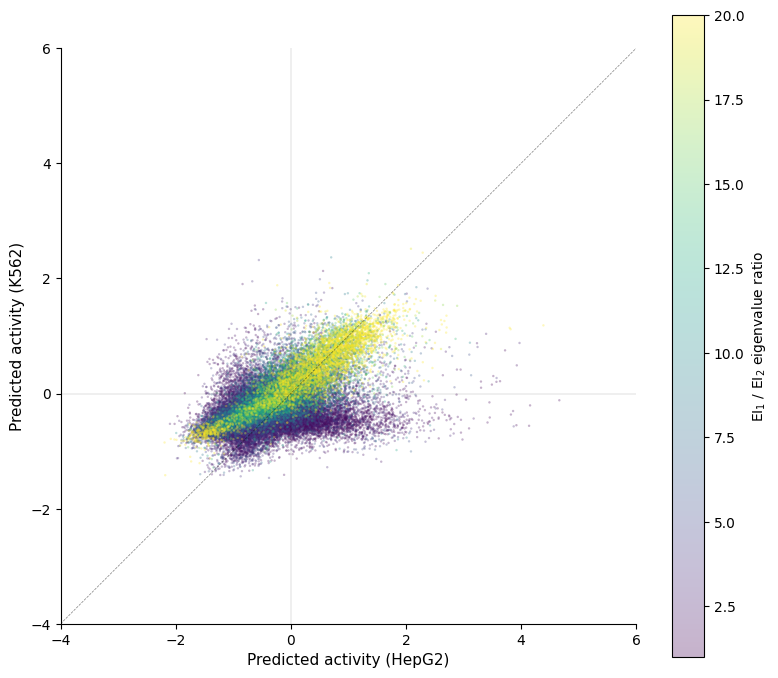

In [8]:
order = np.argsort(ratio)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(em.predictions['HepG2'][order], em.predictions['K562'][order],
                s=3, alpha=0.3, c=ratio[order], cmap='viridis',
                vmin=1, vmax=20, edgecolors='none', rasterized=True)
cbar = plt.colorbar(sc, ax=ax, label='EI$_1$ / EI$_2$ eigenvalue ratio')

lims = [-4, 6]
ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
ax.axhline(0, color='k', lw=0.3, alpha=0.3)
ax.axvline(0, color='k', lw=0.3, alpha=0.3)

ax.set_xlabel('Predicted activity (HepG2)', fontsize=11)
ax.set_ylabel('Predicted activity (K562)', fontsize=11)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

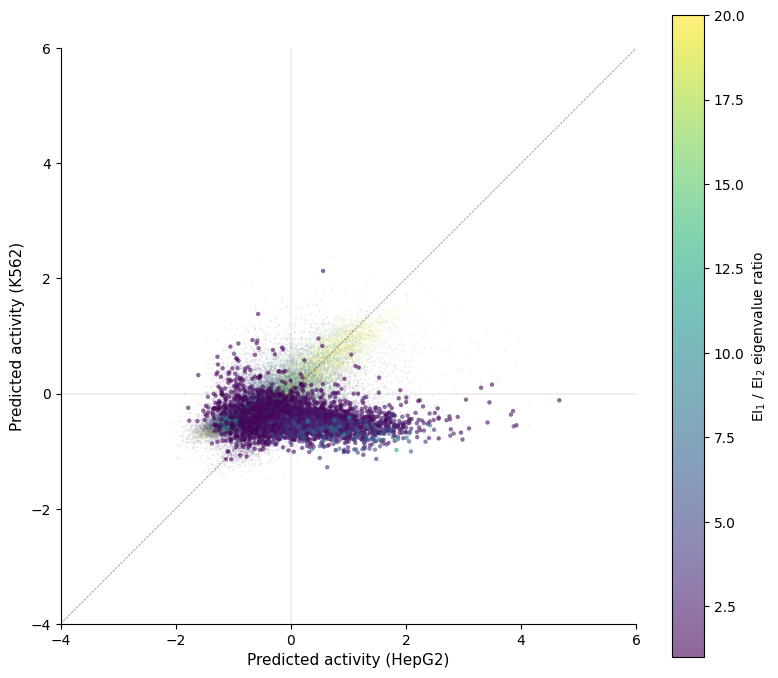

r < 0: 2975 seqs highlighted


In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

# r >= 0: faded viridis
pos = corrs >= 0
pos_order = np.where(pos)[0][np.argsort(ratio[pos])]
ax.scatter(em.predictions['HepG2'][pos_order], em.predictions['K562'][pos_order],
           s=2, alpha=0.08, c=ratio[pos_order], cmap='viridis',
           vmin=1, vmax=20, edgecolors='none', rasterized=True)

# r < 0: full viridis on top
neg = corrs < 0
neg_order = np.where(neg)[0][np.argsort(ratio[neg])]
sc = ax.scatter(em.predictions['HepG2'][neg_order], em.predictions['K562'][neg_order],
                s=10, alpha=0.6, c=ratio[neg_order], cmap='viridis',
                vmin=1, vmax=20, edgecolors='none', rasterized=True)
plt.colorbar(sc, ax=ax, label='EI$_1$ / EI$_2$ eigenvalue ratio')

lims = [-4, 6]
ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
ax.axhline(0, color='k', lw=0.3, alpha=0.3)
ax.axvline(0, color='k', lw=0.3, alpha=0.3)

ax.set_xlabel('Predicted activity (HepG2)', fontsize=11)
ax.set_ylabel('Predicted activity (K562)', fontsize=11)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'r < 0: {neg.sum()} seqs highlighted')

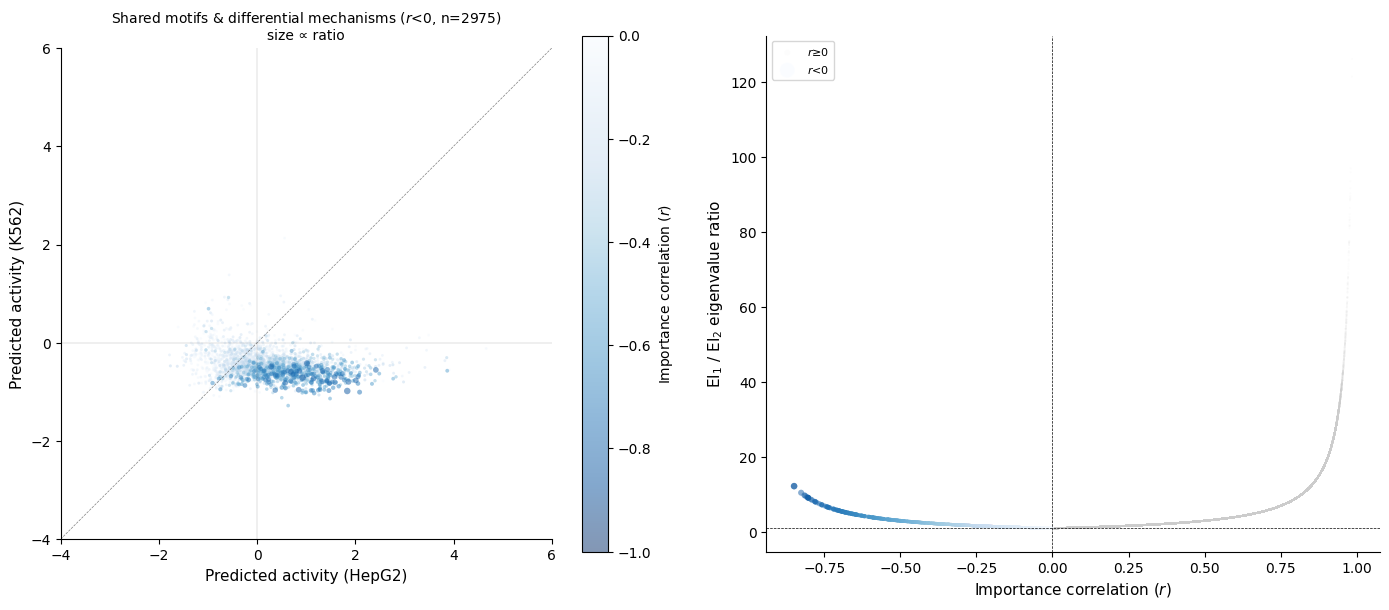

In [10]:
neg = corrs < 0
neg_idx = np.where(neg)[0]

# Sort so highest ratio drawn on top
neg_order = neg_idx[np.argsort(ratio[neg_idx])]

# Color by r, size by ratio
neg_sizes = 2 + 20 * (ratio[neg_order] / ratio[neg_order].max()).clip(0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: HepG2 vs K562, only r<0
sc = ax1.scatter(em.predictions['HepG2'][neg_order], em.predictions['K562'][neg_order],
                 s=neg_sizes, alpha=0.5, c=corrs[neg_order], cmap='Blues_r',
                 vmin=-1, vmax=0, edgecolors='none', rasterized=True)
plt.colorbar(sc, ax=ax1, label='Importance correlation ($r$)')

lims = [-4, 6]
ax1.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
ax1.axhline(0, color='k', lw=0.3, alpha=0.3); ax1.axvline(0, color='k', lw=0.3, alpha=0.3)
ax1.set_xlabel('Predicted activity (HepG2)', fontsize=11)
ax1.set_ylabel('Predicted activity (K562)', fontsize=11)
ax1.set_xlim(lims); ax1.set_ylim(lims); ax1.set_aspect('equal')
ax1.set_title(f'Shared motifs & differential mechanisms ($r$<0, n={neg.sum()})\nsize ∝ ratio', fontsize=10)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: r vs ratio for context
ax2.scatter(corrs[corrs >= 0], ratio[corrs >= 0], s=2, alpha=0.05, c='#cccccc',
            edgecolors='none', rasterized=True, label='$r$≥0')
ax2.scatter(corrs[neg_order], ratio[neg_order], s=neg_sizes, alpha=0.5,
            c=corrs[neg_order], cmap='Blues_r', vmin=-1, vmax=0,
            edgecolors='none', rasterized=True, label='$r$<0')
ax2.axvline(0, color='k', lw=0.5, ls='--')
ax2.axhline(1, color='k', lw=0.5, ls='--')
ax2.set_xlabel('Importance correlation ($r$)', fontsize=11)
ax2.set_ylabel('EI$_1$ / EI$_2$ eigenvalue ratio', fontsize=11)
ax2.legend(fontsize=8, markerscale=3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


--- High ratio (shared motifs, opposing) | seq 56772: C:SLEA_hg18:chr2:210861483-210861650|7:V_HNF3ALPHA_Q6:TGTTTG ---
    r=-0.849, ratio=12.2
    HepG2: actual=1.85 pred=1.84
    K562: actual=-1.21 pred=-0.98

--- Low ratio, strong neg r (distinct motifs, opposing) | seq 38571: HepG2_DNasePeakNoPromoter61479 ---
    r=-0.849, ratio=12.2
    HepG2: actual=0.86 pred=0.93
    K562: actual=-0.76 pred=-0.71


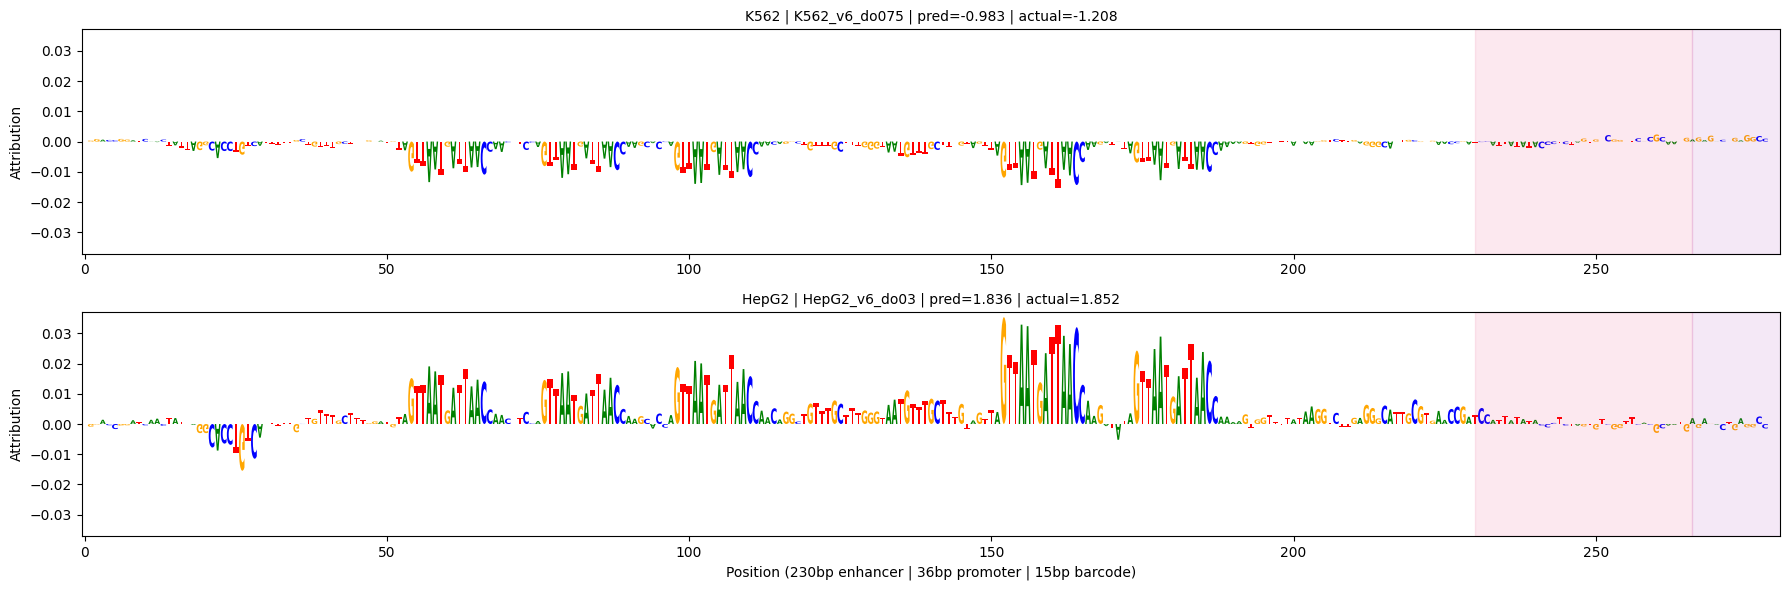

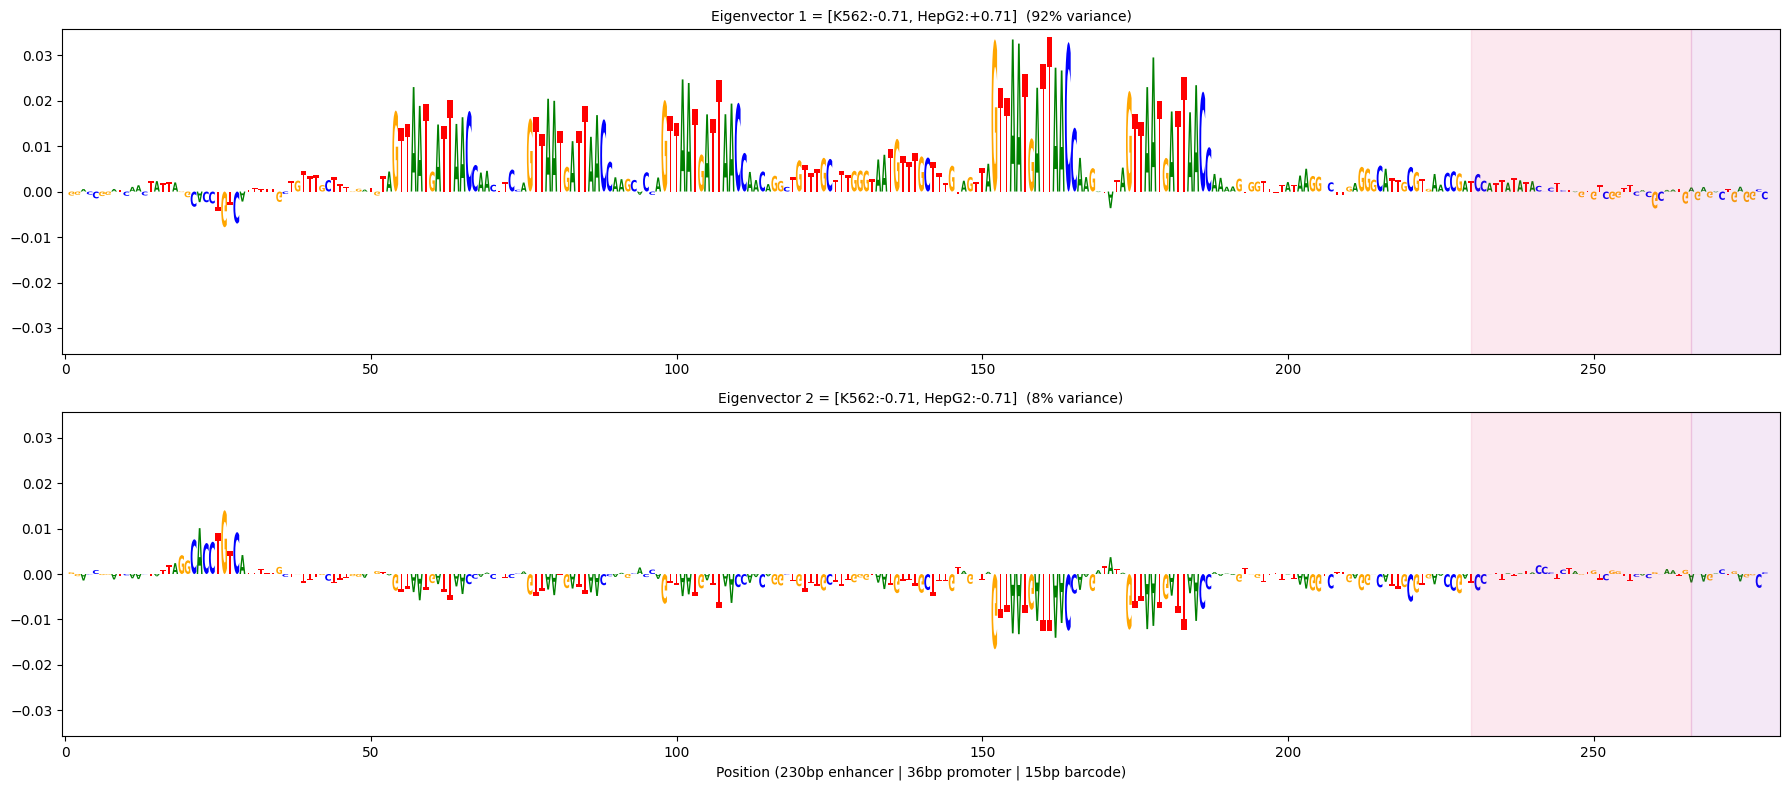

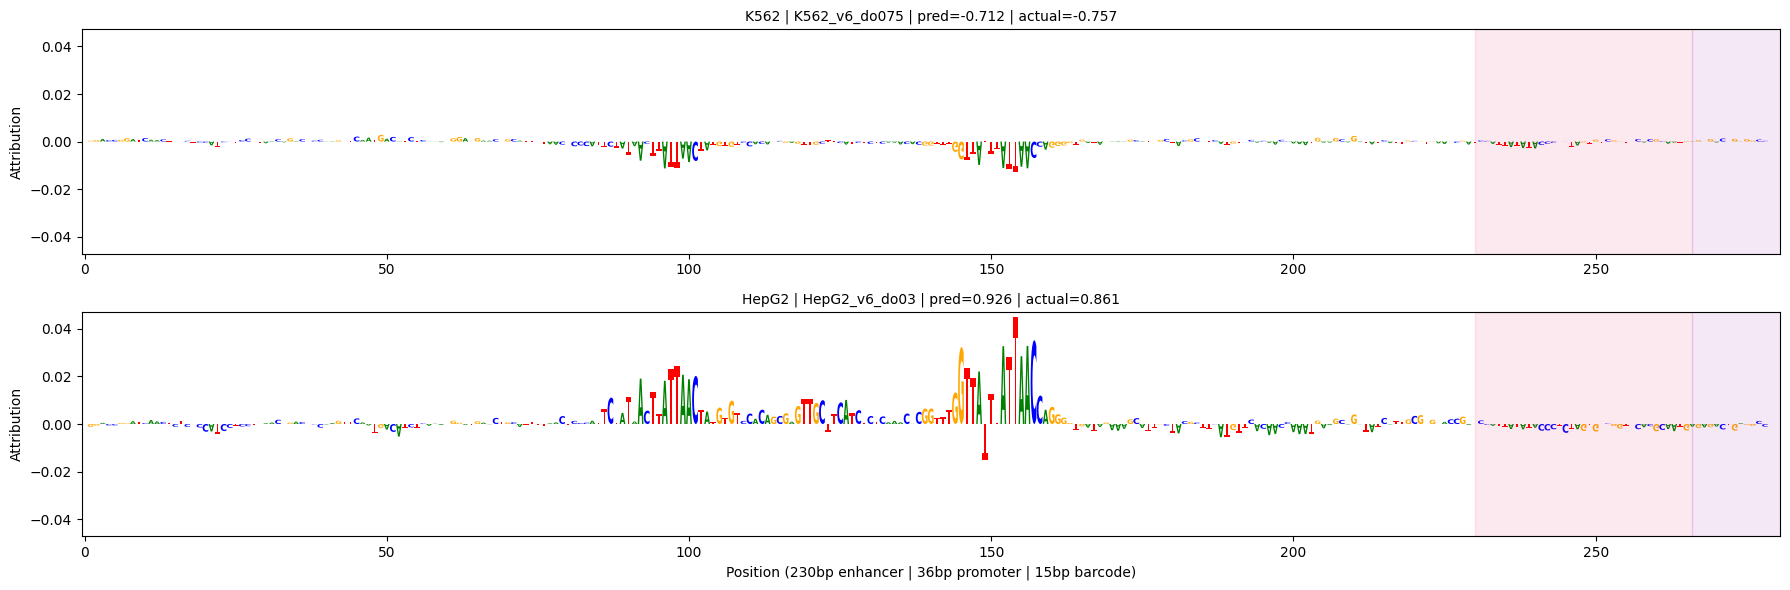

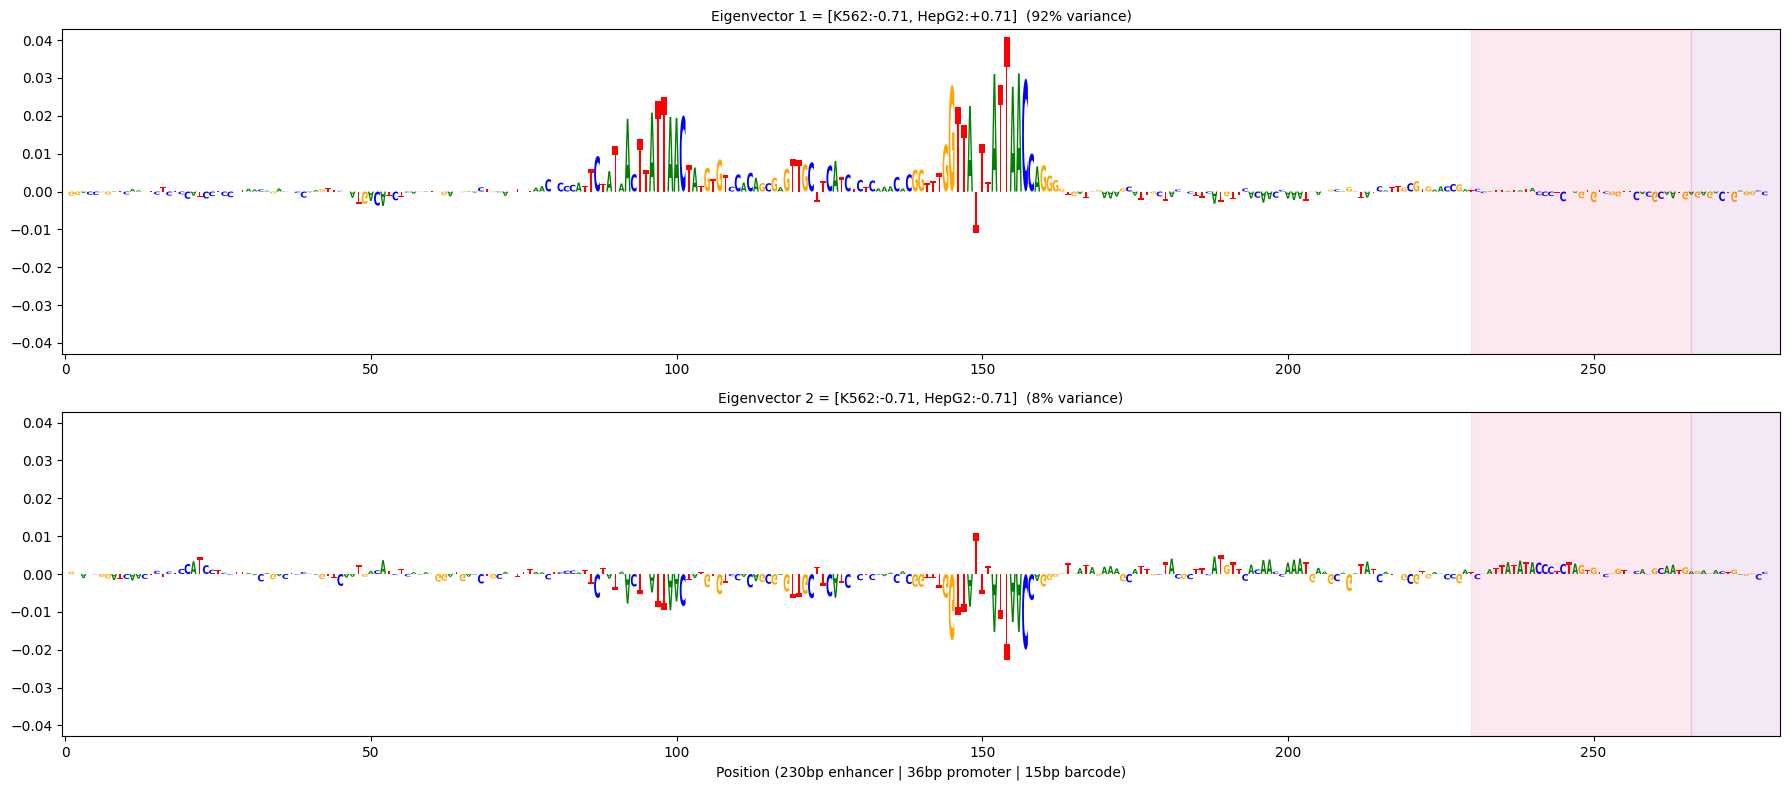

In [11]:
# Select r<0 seqs in quadrant II (HepG2 > 0, K562 < 0)
q2 = (corrs < -.76) & (em.predictions['HepG2'] > 0) & (em.predictions['K562'] < 0)
q2_idx = np.where(q2)[0]
q2_ratios = ratio[q2_idx]

# High ratio: most shared motifs driving opposite directions
hi_idx = q2_idx[np.argmax(q2_ratios)]

# Low ratio but strongly negative r
q2_neg_r = q2_idx[corrs[q2_idx] < np.percentile(corrs[q2_idx], 10)]
lo_idx = q2_neg_r[np.argmin(ratio[q2_neg_r])]

for label, idx in [('High ratio (shared motifs, opposing)', hi_idx),
                    ('Low ratio, strong neg r (distinct motifs, opposing)', lo_idx)]:
    print(f'\n--- {label} | seq {idx}: {df.iloc[idx]["name"][:60]} ---')
    print(f'    r={corrs[idx]:.3f}, ratio={ratio[idx]:.1f}')
    for ct in ['HepG2', 'K562']:
        a = df.iloc[idx][f'{ct}_log2FC']; p = em.predictions[ct][idx]
        print(f'    {ct}: actual={a:.2f} pred={p:.2f}')
    em.plot_attr_logos(seq_idx=idx)
    em.plot_eigen_logos(seq_idx=idx)

pos_hepg2: 133 sequences
HepG2: 505 seqlets
K562: 515 seqlets

=== High ratio (shared motifs, opposing) | seq 56772 ===
    r=-0.849, ratio=12.2
  K562: 7 hits
    [146-171] HNF1B(p=2.8e-06), HNF1A(p=5.1e-06), POU6F1(p=2.7e-03)  (enhancer)
    [ 93-118] HNF1B(p=2.7e-06), HNF1A(p=4.9e-06), POU6F1(p=2.6e-03)  (enhancer)
    [ 48- 73] HNF1B(p=2.8e-06), HNF1A(p=5.1e-06), POU6F1(p=2.7e-03)  (enhancer)
    [168-193] HNF1B(p=2.9e-06), HNF1A(p=5.2e-06), POU6F1(p=2.7e-03)  (enhancer)
    [ 70- 95] HNF1B(p=2.7e-06), HNF1A(p=4.9e-06), POU6F1(p=2.6e-03)  (enhancer)
    [124-149] SOX10(p=6.4e-05), FOXA1(p=3.9e-03), FOXD2(p=4.7e-03)  (enhancer)
    [ 10- 35] SNAI2(p=4.5e-05), PKNOX2(p=6.3e-05), ZEB1(p=6.6e-05)  (enhancer)
  HepG2: 6 hits
    [147-172] HNF1B(p=2.8e-06), HNF1A(p=5.1e-06), POU6F1(p=2.7e-03)  (enhancer)
    [168-193] HNF1B(p=2.9e-06), HNF1A(p=5.2e-06), POU6F1(p=2.7e-03)  (enhancer)
    [ 93-118] HNF1B(p=2.7e-06), HNF1A(p=4.9e-06), POU6F1(p=2.6e-03)  (enhancer)
    [ 49- 74] HNF1B(p=2.8e

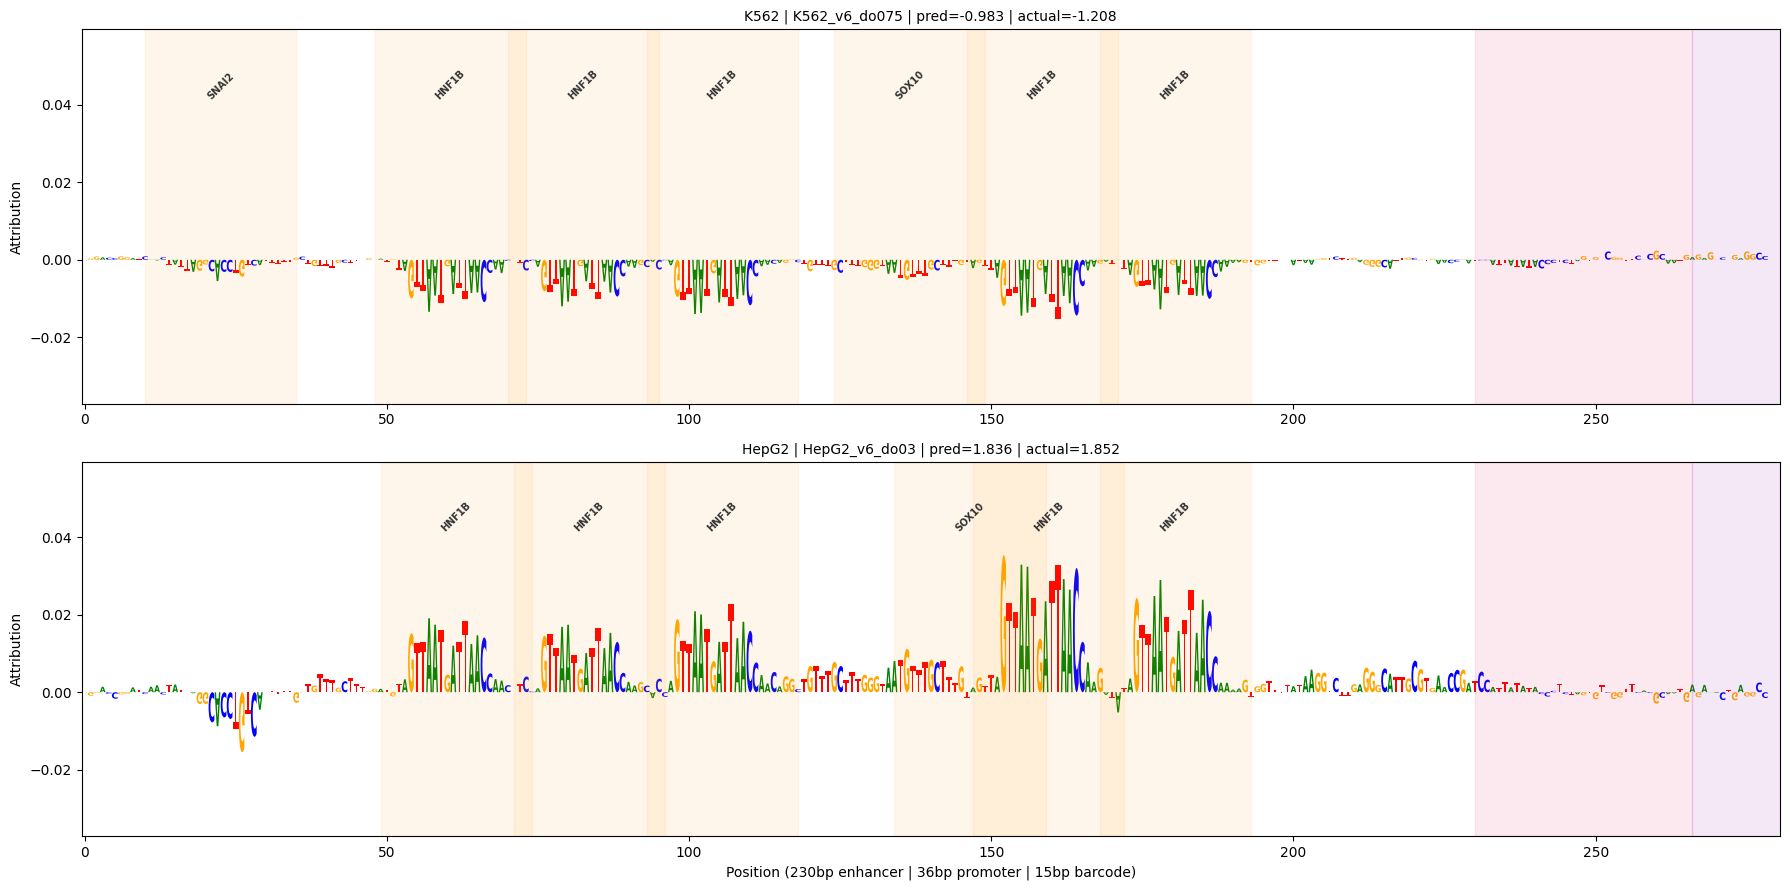

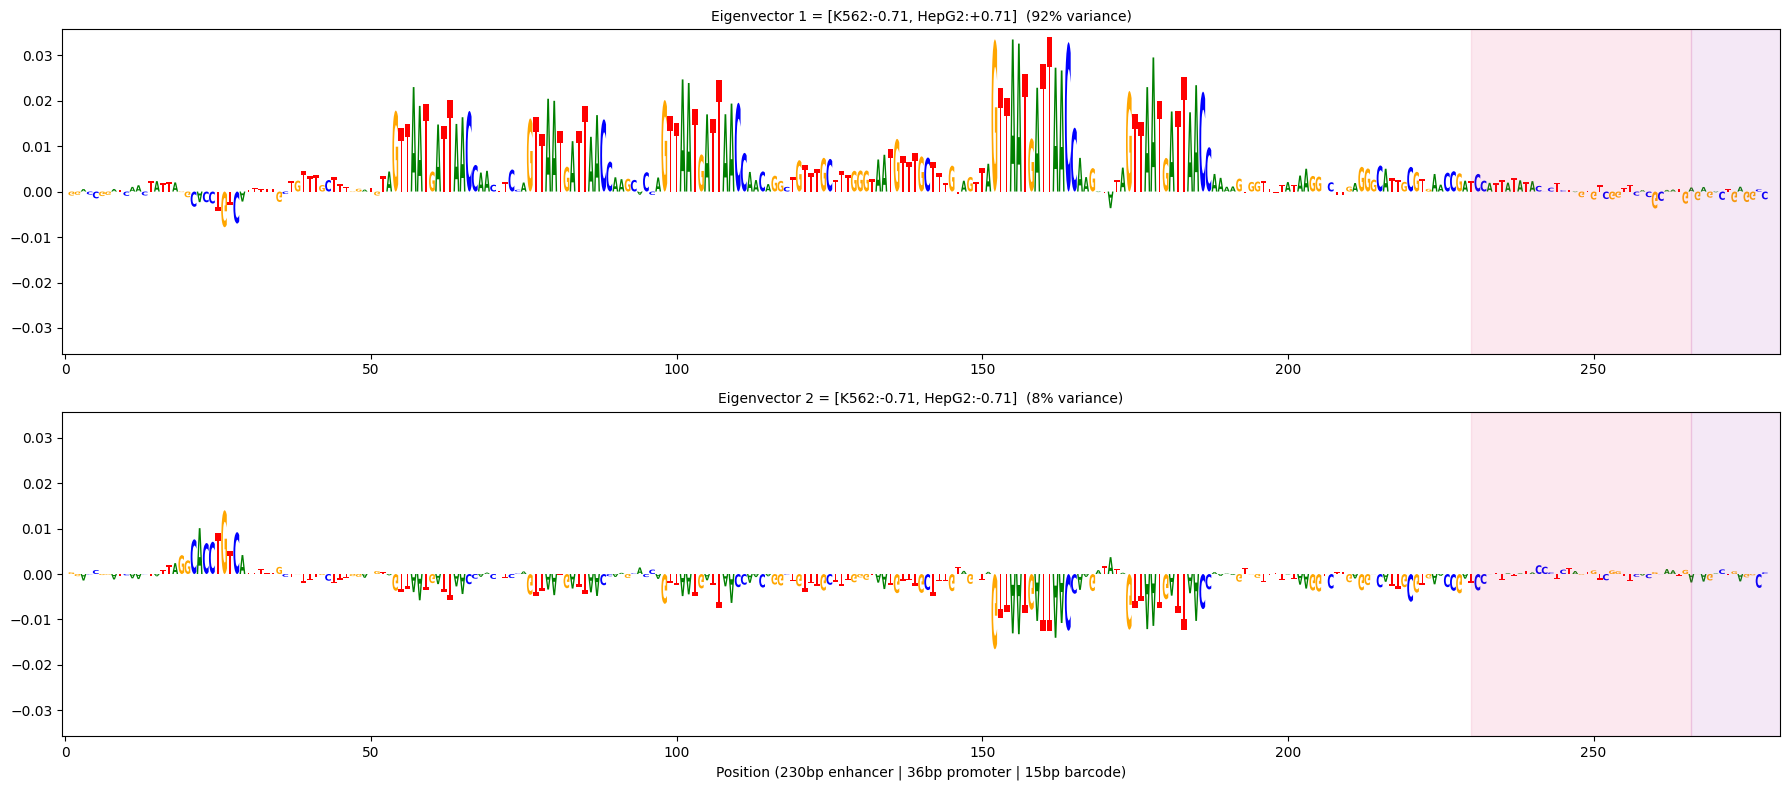

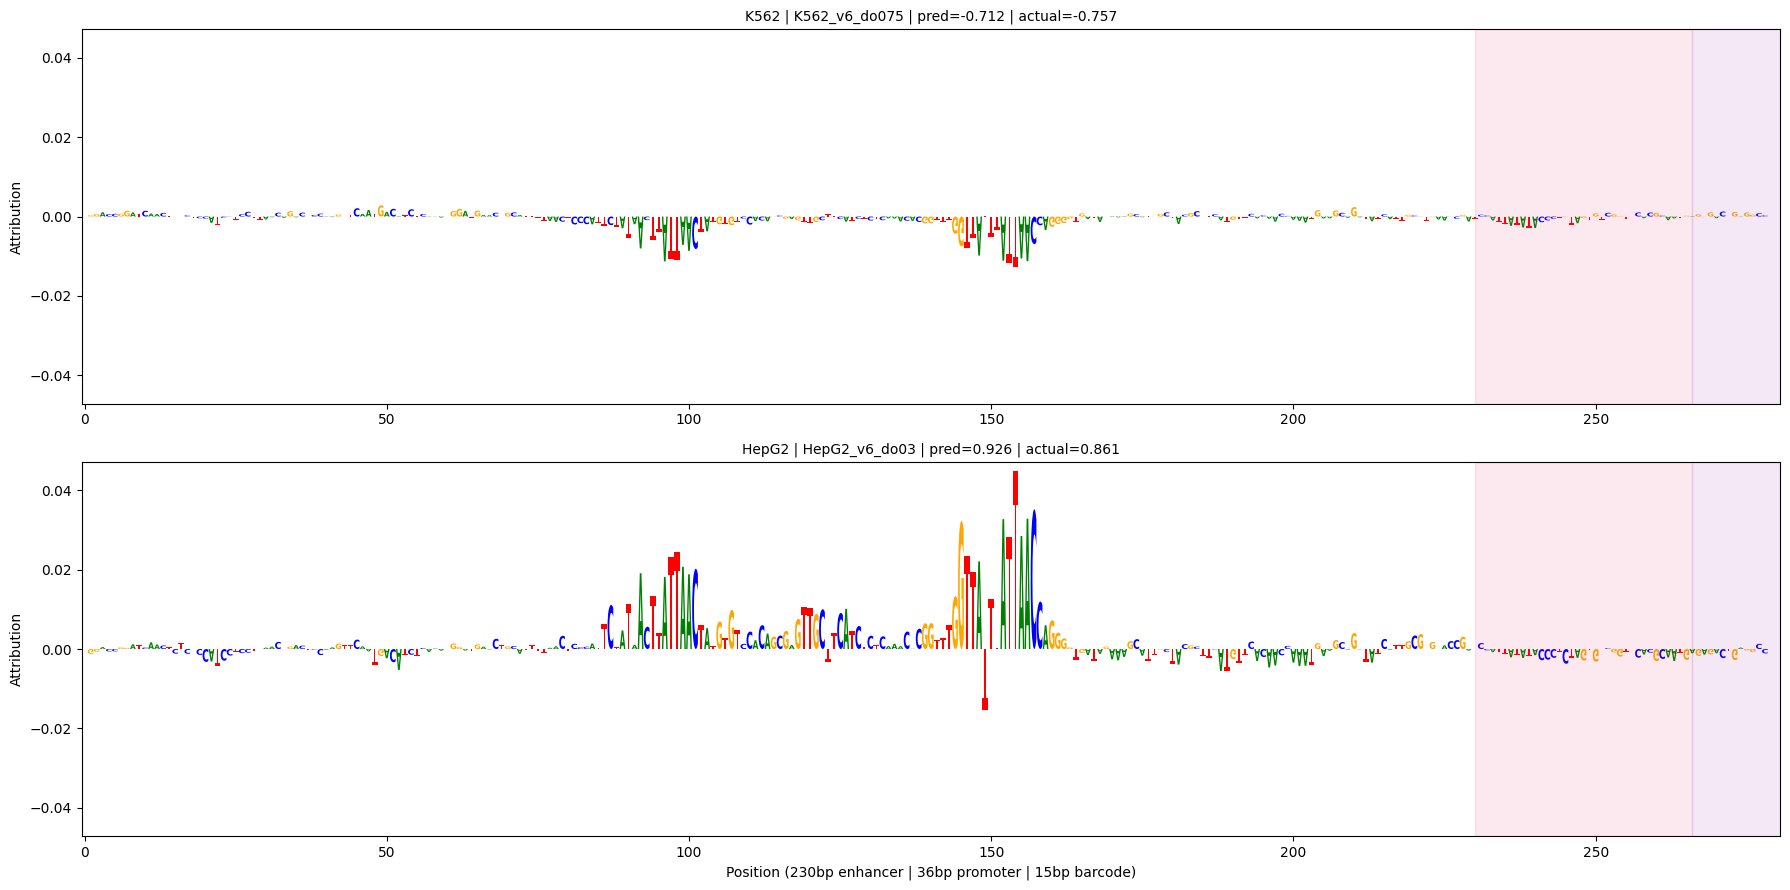

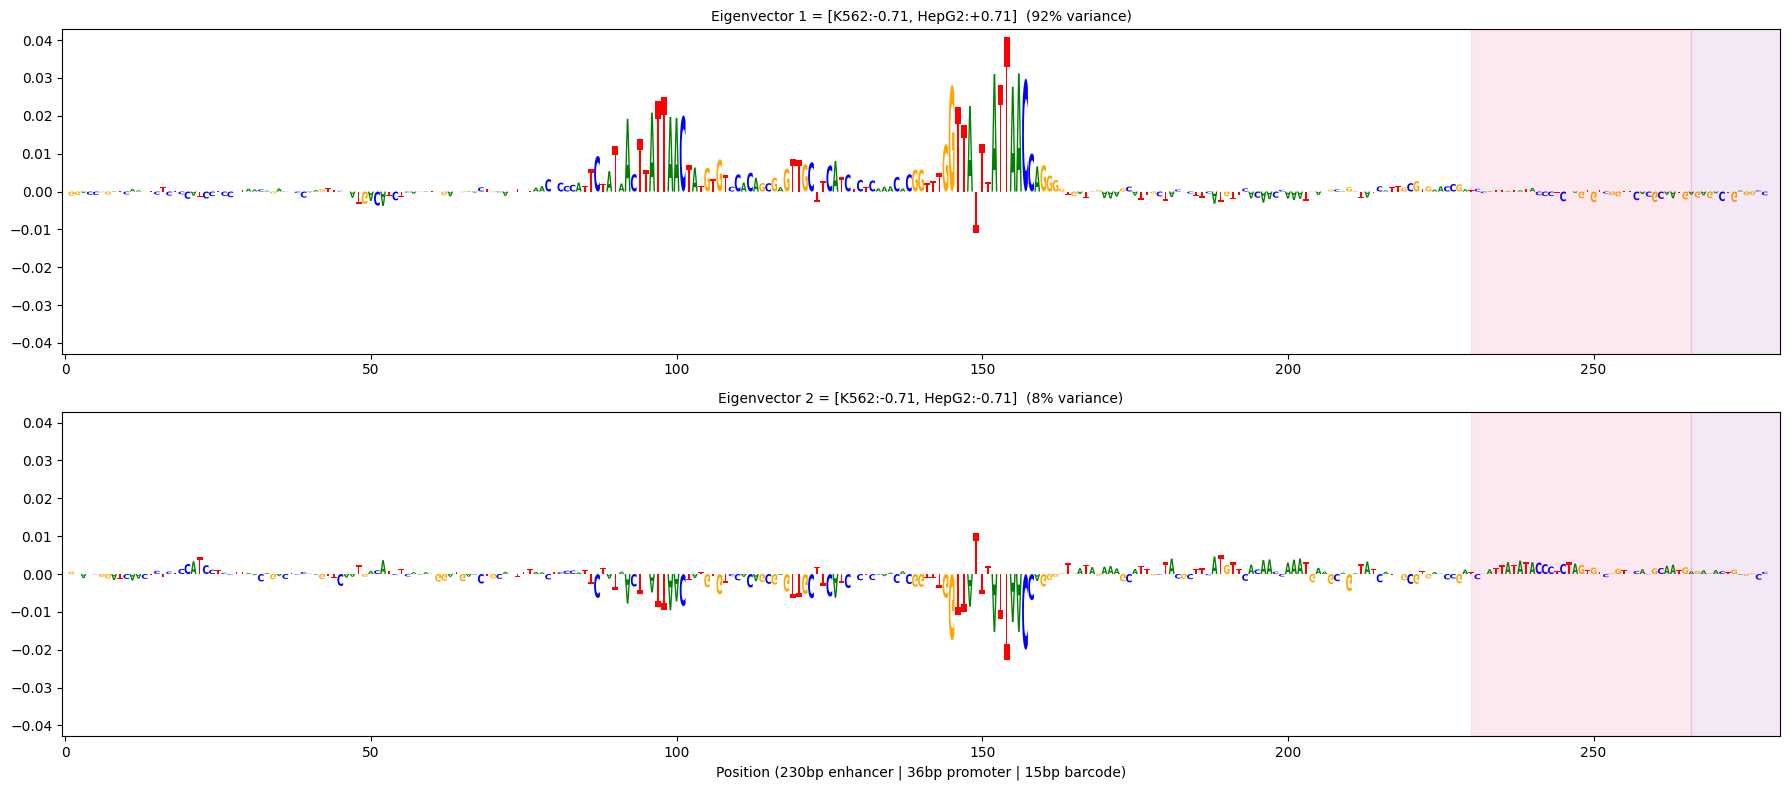

In [12]:
from tangermeme.io import read_meme
from tangermeme.seqlet import tfmodisco_seqlets
from tangermeme.annotate import annotate_seqlets
import torch

meme_file = os.path.join(REPO, 'eigen-interactions', 'motif_db', 'JASPAR2026_vertebrates.meme')
motifs = read_meme(meme_file)
motif_names = list(motifs.keys())

# Use positive HepG2 (Smith) sequences for seqlet FDR
pos_hepg2_mask = df['category'] == 'positive HepG2, Smith'
pos_hepg2_idx = np.where(pos_hepg2_mask)[0]
X_pos = em.X[pos_hepg2_idx].float()
n_total = len(df)

print(f'pos_hepg2: {len(pos_hepg2_idx)} sequences')

# Populate em.motif_hits so plot_attr_logos_with_motifs works
em.motif_hits = {}
for ct in ['HepG2', 'K562']:
    per_seq = [[] for _ in range(n_total)]
    imp_pos = torch.tensor(em.importance[ct][pos_hepg2_idx])
    seqlets = tfmodisco_seqlets(imp_pos, window_size=15, flank=5)
    print(f'{ct}: {len(seqlets)} seqlets')

    if len(seqlets) > 0:
        idxs, pvals = annotate_seqlets(X_pos, seqlets, motifs, n_nearest=3)
        for si in range(len(seqlets)):
            local_idx = int(seqlets.iloc[si, 0])
            global_idx = pos_hepg2_idx[local_idx]
            midx0 = int(idxs[si, 0])
            pv0 = float(pvals[si, 0])
            if midx0 < 0 or pv0 >= 0.05:
                continue
            top_hits = []
            for ki in range(min(3, idxs.shape[1])):
                midx = int(idxs[si, ki])
                pv = float(pvals[si, ki])
                if midx < 0 or pv >= 0.05:
                    continue
                tf_name = motif_names[midx].split()[-1] if ' ' in motif_names[midx] else motif_names[midx].split('_')[-1]
                top_hits.append({'tf': tf_name, 'pval': pv})
            if top_hits:
                per_seq[global_idx].append({
                    'start': int(seqlets.iloc[si, 1]),
                    'end': int(seqlets.iloc[si, 2]),
                    'tf': top_hits[0]['tf'],
                    'pval': pv0,
                    'top_hits': top_hits,
                })
    em.motif_hits[ct] = per_seq

# Show annotated logos
for label, idx in [('High ratio (shared motifs, opposing)', hi_idx),
                    ('Low ratio, strong neg r', lo_idx)]:
    print(f'\n=== {label} | seq {idx} ===')
    print(f'    r={corrs[idx]:.3f}, ratio={ratio[idx]:.1f}')
    em.show_motifs(seq_idx=idx)
    em.plot_attr_logos_with_motifs(seq_idx=idx)
    em.plot_eigen_logos(seq_idx=idx)

In [13]:
import pickle

eigen_cache = os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl')

if os.path.exists(eigen_cache):
    with open(eigen_cache, 'rb') as f:
        cached = pickle.load(f)
    em.motif_hits = cached['motif_hits']
    em.eigen_results = cached['eigen_results']
    ei1_vecs = cached['ei1_vecs']
    ei2_vecs = cached['ei2_vecs']
    ei1_var = cached['ei1_var']
    ei1_evals = cached['ei1_evals']
    ei2_evals = cached['ei2_evals']
    ratio = cached['ratio']
    corrs = cached['corrs']
    has_motifs_both = cached['has_motifs_both']
    print(f'Loaded eigen analysis from {eigen_cache}')
    print(f'Seqs with motifs in both cell lines: {has_motifs_both.sum()} / {len(has_motifs_both)}')
else:
    # Run motif annotation on full library
    em.annotate_motifs(window_size=15, flank=5)

    # Filter: seqs with at least one motif hit in BOTH cell lines
    has_motifs_both = np.array([
        len(em.motif_hits['K562'][i]) > 0 and len(em.motif_hits['HepG2'][i]) > 0
        for i in range(len(df))
    ])
    print(f'Seqs with motifs in both cell lines: {has_motifs_both.sum()} / {len(has_motifs_both)}')

    cached = {
        'motif_hits': em.motif_hits,
        'eigen_results': em.eigen_results,
        'ei1_vecs': ei1_vecs,
        'ei2_vecs': ei2_vecs,
        'ei1_var': ei1_var,
        'ei1_evals': ei1_evals,
        'ei2_evals': ei2_evals,
        'ratio': ratio,
        'corrs': corrs,
        'has_motifs_both': has_motifs_both,
        'predictions': {ct: em.predictions[ct] for ct in em.cell_types},
    }
    with open(eigen_cache, 'wb') as f:
        pickle.dump(cached, f)
    print(f'Saved eigen analysis to {eigen_cache}')

  K562: 37998 motif hits (p<0.05)
  HepG2: 38313 motif hits (p<0.05)
Seqs with motifs in both cell lines: 13561 / 56975
Saved eigen analysis to /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/eigen_analysis.pkl
